# Однофакторная регрессия

Зависимая переменная: `Stress Level`  
Фактор: `Sleep Duration`

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
from pathlib import Path

data_path = Path("data/sleep.csv")
if not data_path.exists():
    data_path = Path("data.csv")

df = pd.read_csv(data_path)
df = df[["Sleep Duration", "Stress Level"]].dropna().copy()
df.head()


,Sleep Duration,Stress Level
0,6.1,6
1,6.2,8
2,6.2,8
3,5.9,8
4,5.9,8


Выбрана зависимость уровня стресса от продолжительности сна.

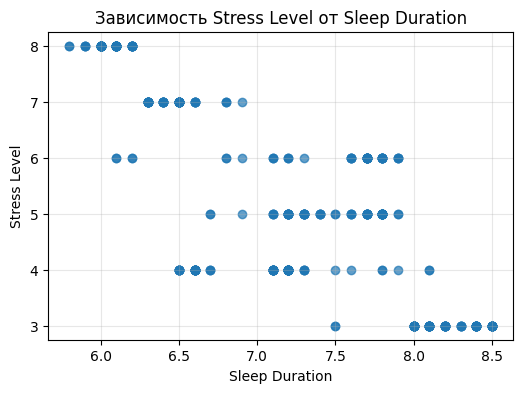

In [2]:

X = df[["Sleep Duration"]]
y = df["Stress Level"]

plt.figure(figsize=(6, 4))
plt.scatter(X["Sleep Duration"], y, alpha=0.7)
plt.xlabel("Sleep Duration")
plt.ylabel("Stress Level")
plt.title("Зависимость Stress Level от Sleep Duration")
plt.grid(True, alpha=0.3)
plt.show()


In [3]:

train = df.sample(frac=0.75, random_state=56)
test = df.drop(train.index).copy()

X_train = train[["Sleep Duration"]]
y_train = train["Stress Level"]
X_test = test[["Sleep Duration"]]
y_test = test["Stress Level"]

X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test, has_constant="add")

model = sm.OLS(y_train, X_train_const).fit()
residuals = model.resid
y_train_pred = model.predict(X_train_const)
y_test_pred = model.predict(X_test_const)

print(model.summary())

a = model.params["const"]
b = model.params["Sleep Duration"]
print(f"Уравнение регрессии: y = {a:.2f} + ({b:.2f}) * x")


                            OLS Regression Results                            
Dep. Variable:           Stress Level   R-squared:                       0.669
Model:                            OLS   Adj. R-squared:                  0.667
Method:                 Least Squares   F-statistic:                     560.8
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.26e-68
Time:                        05:23:29   Log-Likelihood:                -403.87
No. Observations:                 280   AIC:                             811.7
Df Residuals:                     278   BIC:                             819.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             18.4274      0.551     33.


**Проверяемые гипотезы**

- Для модели в целом:  
  `H0` — линейная связь между `Sleep Duration` и `Stress Level` отсутствует.  
  `H1` — линейная связь присутствует.

- Для коэффициента при факторе:  
  `H0` — коэффициент при `Sleep Duration` равен 0.  
  `H1` — коэффициент при `Sleep Duration` не равен 0.

- Для свободного члена:  
  `H0` — свободный член равен 0.  
  `H1` — свободный член не равен 0.


In [4]:

r2 = model.rsquared
r2_adj = model.rsquared_adj
sigma2 = model.scale
mean_approx_error = np.mean(np.abs((y_train - y_train_pred) / y_train)) * 100

print(f"R^2 = {r2:.4f}")
print(f"Adjusted R^2 = {r2_adj:.4f}")
print(f"Остаточная дисперсия = {sigma2:.4f}")
print(f"Средняя ошибка аппроксимации = {mean_approx_error:.2f}%")
print()
print(f"F-statistic p-value = {model.f_pvalue:.4g}")
print("p-value коэффициентов:")
print(model.pvalues)

if model.f_pvalue < 0.05:
    print("\nВывод по F-критерию: H0 отвергается, модель в целом статистически значима.")
else:
    print("\nВывод по F-критерию: нет оснований отвергать H0, линейная связь не подтверждена.")

if model.pvalues["Sleep Duration"] < 0.05:
    print("Вывод по коэффициенту при факторе: H0 отвергается, фактор значим.")
else:
    print("Вывод по коэффициенту при факторе: нет оснований отвергать H0, фактор незначим.")

if model.pvalues["const"] < 0.05:
    print("Вывод по свободному члену: H0 отвергается, свободный член значим.")
else:
    print("Вывод по свободному члену: нет оснований отвергать H0, свободный член незначим.")


R^2 = 0.6686
Adjusted R^2 = 0.6674
Остаточная дисперсия = 1.0556
Средняя ошибка аппроксимации = 16.80%

F-statistic p-value = 1.265e-68
p-value коэффициентов:
const             2.199191e-99
Sleep Duration    1.264517e-68
dtype: float64

Вывод по F-критерию: H0 отвергается, модель в целом статистически значима.
Вывод по коэффициенту при факторе: H0 отвергается, фактор значим.
Вывод по свободному члену: H0 отвергается, свободный член значим.



**Проверка предпосылок**

- Для среднего остатка:  
  `H0` — математическое ожидание остатков равно 0.  
  `H1` — математическое ожидание остатков не равно 0.

- Для дисперсии остатков:  
  `H0` — остатки гомоскедастичны.  
  `H1` — остатки гетероскедастичны.

- Для автокорреляции:  
  `H0` — автокорреляция остатков отсутствует.  
  `H1` — автокорреляция остатков присутствует.

- Для нормальности:  
  `H0` — остатки распределены нормально.  
  `H1` — остатки не распределены нормально.


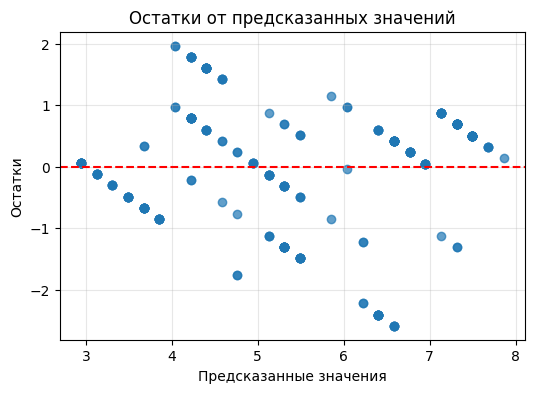

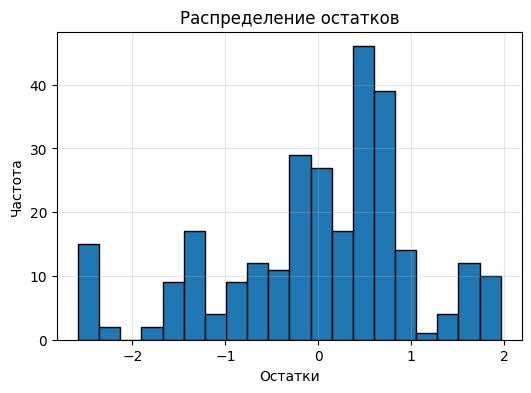

Среднее остатков = -0.000000
t_расч = -0.000000
t_табл = 1.968503
Вывод: H0 не отвергается, математическое ожидание остатков можно считать равным 0.

Breusch-Pagan p-value = 0.416335
Вывод: нет оснований отвергать H0, явных признаков гетероскедастичности нет.

Durbin-Watson = 2.124647
Вывод: выраженной автокорреляции остатков не обнаружено.

Shapiro-Wilk p-value = 2.62742e-08
Вывод: H0 отвергается, остатки не распределены нормально.


In [5]:

plt.figure(figsize=(6, 4))
plt.scatter(model.fittedvalues, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("Остатки от предсказанных значений")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20, edgecolor="black")
plt.title("Распределение остатков")
plt.xlabel("Остатки")
plt.ylabel("Частота")
plt.grid(True, alpha=0.3)
plt.show()

mean_res = residuals.mean()
std_res = residuals.std(ddof=1)
t_calc = mean_res / (std_res / np.sqrt(len(residuals)))
t_crit = stats.t.ppf(1 - 0.05 / 2, len(residuals) - 1)

bp_lm, bp_pvalue, bp_fvalue, bp_fpvalue = het_breuschpagan(residuals, model.model.exog)
dw_stat = durbin_watson(residuals)
shapiro_stat, shapiro_pvalue = stats.shapiro(residuals)

print(f"Среднее остатков = {mean_res:.6f}")
print(f"t_расч = {t_calc:.6f}")
print(f"t_табл = {t_crit:.6f}")
if abs(t_calc) < t_crit:
    print("Вывод: H0 не отвергается, математическое ожидание остатков можно считать равным 0.")
else:
    print("Вывод: H0 отвергается, математическое ожидание остатков отлично от 0.")

print()
print(f"Breusch-Pagan p-value = {bp_pvalue:.6f}")
if bp_pvalue < 0.05:
    print("Вывод: H0 отвергается, присутствует гетероскедастичность.")
else:
    print("Вывод: нет оснований отвергать H0, явных признаков гетероскедастичности нет.")

print()
print(f"Durbin-Watson = {dw_stat:.6f}")
if dw_stat < 1.5:
    print("Вывод: наблюдается положительная автокорреляция остатков.")
elif dw_stat > 2.5:
    print("Вывод: наблюдается отрицательная автокорреляция остатков.")
else:
    print("Вывод: выраженной автокорреляции остатков не обнаружено.")

print()
print(f"Shapiro-Wilk p-value = {shapiro_pvalue:.6g}")
if shapiro_pvalue < 0.05:
    print("Вывод: H0 отвергается, остатки не распределены нормально.")
else:
    print("Вывод: нет оснований отвергать H0, нормальность остатков не нарушена.")


MAE на тестовой выборке = 0.8363
MAPE на тестовой выборке = 18.62%


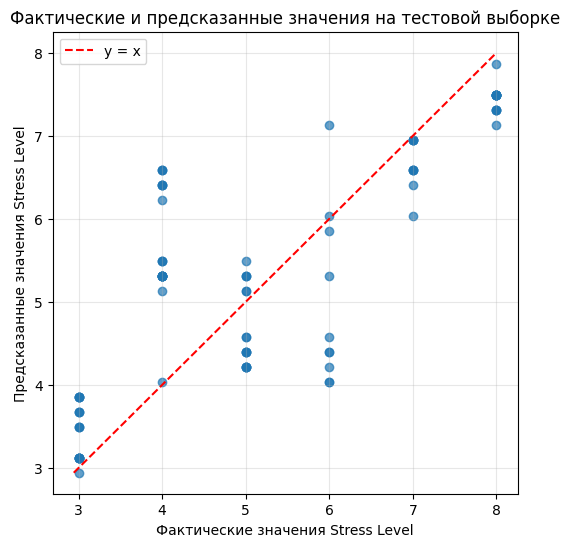

In [6]:

mae_test = np.mean(np.abs(y_test - y_test_pred))
mape_test = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

print(f"MAE на тестовой выборке = {mae_test:.4f}")
print(f"MAPE на тестовой выборке = {mape_test:.2f}%")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.7)
line_min = min(y_test.min(), y_test_pred.min())
line_max = max(y_test.max(), y_test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], "r--", label="y = x")
plt.xlabel("Фактические значения Stress Level")
plt.ylabel("Предсказанные значения Stress Level")
plt.title("Фактические и предсказанные значения на тестовой выборке")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



### Вывод

Между продолжительностью сна и уровнем стресса наблюдается статистически значимая обратная линейная связь: при увеличении `Sleep Duration` уровень `Stress Level` снижается. Модель в целом значима, коэффициенты значимы, свободный член исключать не требуется. Среднее остатков близко к нулю, явных признаков гетероскедастичности нет, выраженной автокорреляции не обнаружено, однако нормальность остатков нарушена. Поэтому модель можно использовать для описания общей зависимости и прогноза, но с учетом того, что часть предпосылок МНК выполняется не полностью.
